# Income Tax Fraud Detection — Enterprise ML Pipeline

**What this notebook actually trains:** a classifier on the UCI **Census Income** dataset that
predicts whether a person's income is above or below $50K, using demographic and employment
census fields (age, workclass, education, marital status, occupation, race, sex, capital
gain/loss, hours worked, native country).

**What it does *not* do:** measure fraud. There is no filing history, audit outcome, or
reported-vs-verified discrepancy anywhere in this data — "high income" is not evidence of
fraud. Treating it as a fraud proxy means the model's real function is predicting income from
demographic attributes (including race, sex, marital status, and national origin) and handing
that prediction to a downstream fraud/audit process. If this is ever wired to a real decision
about who gets investigated or audited, that would mean using protected attributes to drive an
investigative outcome with no actual fraud signal behind it. Treat this notebook as an
income-classification exercise, not an audit-worthy fraud model, unless it is retrained on data
with real fraud/audit outcomes as the label.

**Changes from the previous version of this notebook**, based on a review that found the saved
notebook errored out partway through and never finished running:
- Hyperparameter search now runs in parallel (`n_jobs=-1`) instead of one fit at a time — the
  previous version hung on a sequential 60-fit Gradient Boosting search and was interrupted
  before finishing.
- Fixing that also surfaced a second bug the interrupted run never reached: `scoring="f1"`
  silently assumes `pos_label=1`, which doesn't exist for the `"<=50K"`/`">50K"` string labels
  used here. Every candidate was scoring `NaN`. Replaced with an explicit scorer.
- Model selection and decision-threshold tuning now use a dedicated **validation** split
  instead of the test set, so the test set is touched exactly once, at the end, to report final
  numbers — previously it was reused across five separate steps.
- Class imbalance (76% / 24%) is now handled consistently: Random Forest and Decision Tree get
  `class_weight="balanced"` (they support it natively and weren't using it), Gradient Boosting
  and Naive Bayes get weighted via `sample_weight`. MLP and KNN have no native reweighting
  mechanism in scikit-learn, which is now noted explicitly rather than left as a silent gap.
- `predict_proba(...)[:, 1]` (four places) is replaced with an explicit lookup of the positive
  class's column, rather than relying on alphabetical label ordering.
- The global `warnings.filterwarnings("ignore", category=UserWarning)` is removed —
  it was also hiding `ConvergenceWarning` from the neural network.
- Saved metadata now includes the scikit-learn/pandas/numpy/Python versions the model was
  trained with, since a pickled pipeline loaded by a separate service is exactly where a
  version mismatch silently breaks.
- The duplicate bake-off table (old sections 7 and 11) is consolidated into one.

**Design principles:** reproducible splits, leakage-safe `sklearn` pipelines, imbalance-aware
metrics, hyperparameter search inside CV, a train / validation / test split so the test set is
touched exactly once, and serialized artifacts for the Django API in `fraud_app/`.

## 1. Configuration

In [2]:
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

# No blanket warning suppression here on purpose — ConvergenceWarning (a UserWarning
# subclass) is exactly the signal that would tell us if the MLP didn't converge, and a
# global filter was hiding it in the previous version.

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001


def resolve_project_root() -> Path:
    """Find the folder that contains census-income.csv (works in Jupyter and CLI)."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "census-income.csv").exists():
            return candidate
    return Path.cwd()


# --- Reproducibility & paths ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NOTEBOOK_DIR = resolve_project_root()
DATA_PATH = NOTEBOOK_DIR / "census-income.csv"
ARTIFACT_DIR = NOTEBOOK_DIR / "artifacts"
# fraud_app/ is the existing Django app's expected model location — kept as-is so this
# still drops into that integration; see the caveat above about what the model can
# responsibly be used for.
MODEL_PATH = NOTEBOOK_DIR / "fraud_app" / "model.pkl"
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_PATH.parent.mkdir(exist_ok=True)

POSITIVE_LABEL = ">50K"
NEGATIVE_LABEL = "<=50K"
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.25  # 25% of the remaining 80% of rows -> 20% of the full dataset
CV_FOLDS = 5
N_JOBS = -1  # was 1 — a sequential 60-fit search on Gradient Boosting is what hung before

FEATURE_COLUMNS = [
    "age",
    "workclass",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
]
TARGET_COLUMN = "income"

CATEGORICAL_FEATURES = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]
NUMERIC_FEATURES = [c for c in FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]

# The "f1" scoring shorthand resolves to f1_score(pos_label=1), which raises on string
# labels ("pos_label=1 is not a valid label"). Bind pos_label explicitly instead.
F1_SCORER = make_scorer(f1_score, pos_label=POSITIVE_LABEL, zero_division=0)


def positive_class_index(fitted_estimator, positive_label: str = POSITIVE_LABEL) -> int:
    """Index of `positive_label` in a fitted estimator's classes_.

    predict_proba(...)[:, 1] happened to be correct four times over in the previous
    version because sklearn sorts string classes alphabetically and "<" sorts before
    ">" — but that's implicit and silently breaks if the labels ever change. This looks
    the index up explicitly instead.
    """
    return list(fitted_estimator.classes_).index(positive_label)


logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("fraud-training")

## 2. Load & validate data

In [3]:
def clean_census_frame(raw: pd.DataFrame) -> pd.DataFrame:
    """Normalize whitespace and standardize missing tokens."""
    df = raw.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"?": np.nan, "": np.nan})
    return df


if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

raw_df = pd.read_csv(DATA_PATH)
df = clean_census_frame(raw_df)

missing = df[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().sum()
logger.info("Loaded %s rows from %s", f"{len(df):,}", DATA_PATH.name)
display(df[FEATURE_COLUMNS + [TARGET_COLUMN]].head())
print("\nMissing values (after cleaning):")
print(missing[missing > 0].sort_values(ascending=False))
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).round(4))

INFO | Loaded 48,842 rows from census-income.csv


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K



Missing values (after cleaning):
occupation        2809
workclass         2799
native-country     857
dtype: int64

Target distribution:
income
<=50K    0.7607
>50K     0.2393
Name: proportion, dtype: float64


## 3. Exploratory analysis

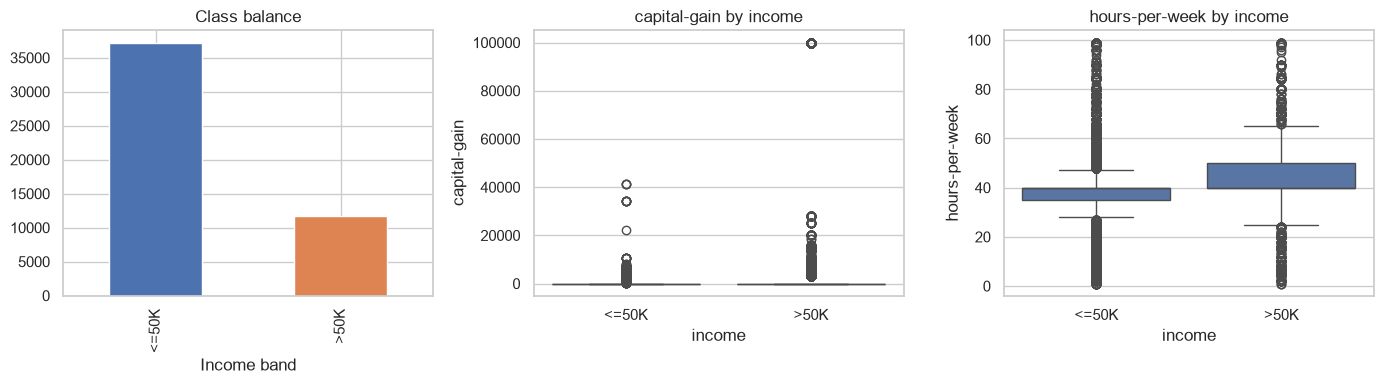

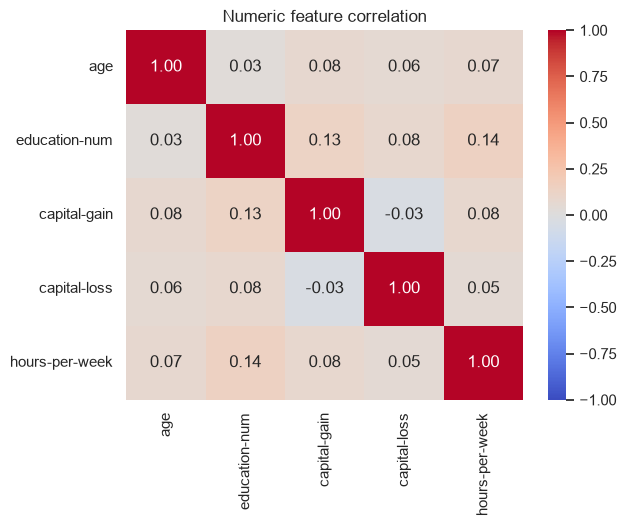

In [4]:
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df[TARGET_COLUMN].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class balance")
axes[0].set_xlabel("Income band")

for ax, col in zip(axes[1:], ["capital-gain", "hours-per-week"]):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, ax=ax)
    ax.set_title(f"{col} by income")

plt.tight_layout()
plt.show()

corr_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Numeric feature correlation")
plt.show()

## 4. Run Enterprise Pipeline

We now use the refactored modular pipeline to perform reproducible splits, train candidate models, select the best model using a validation set, and evaluate it on the holdout test set.

In [ ]:
import sys
from pathlib import Path

# Add project root to sys.path
project_root = str(resolve_project_root())
if project_root not in sys.path:
    sys.path.append(project_root)

from sklearn.model_selection import train_test_split
from ml.src.data_loader import get_train_test_split
from ml.src.preprocessing import build_preprocessor
from ml.src.model import train_model
from ml.src.evaluate import evaluate_model
from ml.src.config import VALIDATION_SIZE, RANDOM_STATE

logger.info("Splitting dataset into train/validation/test sets")
X_train, X_test, y_train, y_test = get_train_test_split(df)
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

logger.info("Building preprocessing pipeline")
preprocessor = build_preprocessor()

logger.info("Comparing candidate models and tuning hyperparameters")
comparison, best_pipeline = train_model(X_train, y_train, preprocessor, X_val, y_val)

print("\n--- Best Model Selection ---")
print(f"Selected Model: {comparison['best_model_name']}")
print(f"Best F1 Score: {comparison['best_metrics']['f1']:.4f}")

logger.info("Evaluating selected model on test data")
metrics = evaluate_model(best_pipeline, X_test, y_test)

print("\n--- Test Set Performance ---")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")
